In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("movie_picks_dataset.csv")
df

,movie_id,genre,language,runtime_min,critic_score,audience_score,release_year,num_awards,recommend
0,1,animation,hindi,128,26.8,90.9,2010,5,1
1,2,animation,english,105,63.5,95.6,2018,6,1
2,3,thriller,english,168,92.7,68.6,2013,2,1
3,4,animation,english,165,33.5,42.3,2012,11,0
4,5,animation,english,177,83.1,81.7,2015,4,1
...,...,...,...,...,...,...,...,...,...
1995,1996,action,english,81,61.3,35.1,2018,1,0
1996,1997,thriller,hindi,170,98.1,35.3,2021,0,1
1997,1998,comedy,spanish,80,57.0,29.7,1999,2,0
1998,1999,drama,english,120,95.0,56.2,2007,11,1


In [2]:
df.shape

(2000, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        2000 non-null   int64  
 1   genre           2000 non-null   str    
 2   language        2000 non-null   str    
 3   runtime_min     2000 non-null   int64  
 4   critic_score    2000 non-null   float64
 5   audience_score  2000 non-null   float64
 6   release_year    2000 non-null   int64  
 7   num_awards      2000 non-null   int64  
 8   recommend       2000 non-null   int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 165.7 KB


In [4]:
df.describe()

,movie_id,runtime_min,critic_score,audience_score,release_year,num_awards,recommend
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,127.663000,60.113800,60.197700,2009.512500,5.617000,0.500000
std,577.494589,30.188443,23.367996,23.138099,8.550052,3.400161,0.500125
min,1.000000,75.000000,20.000000,20.000000,1995.000000,0.000000,0.000000
25%,500.750000,101.000000,39.800000,39.700000,2002.000000,3.000000,0.000000
50%,1000.500000,128.000000,59.750000,59.950000,2010.000000,6.000000,0.500000
75%,1500.250000,154.000000,81.100000,80.400000,2017.000000,8.250000,1.000000
max,2000.000000,179.000000,100.000000,100.000000,2024.000000,11.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

movie_id          0
genre             0
language          0
runtime_min       0
critic_score      0
audience_score    0
release_year      0
num_awards        0
recommend         0
dtype: int64

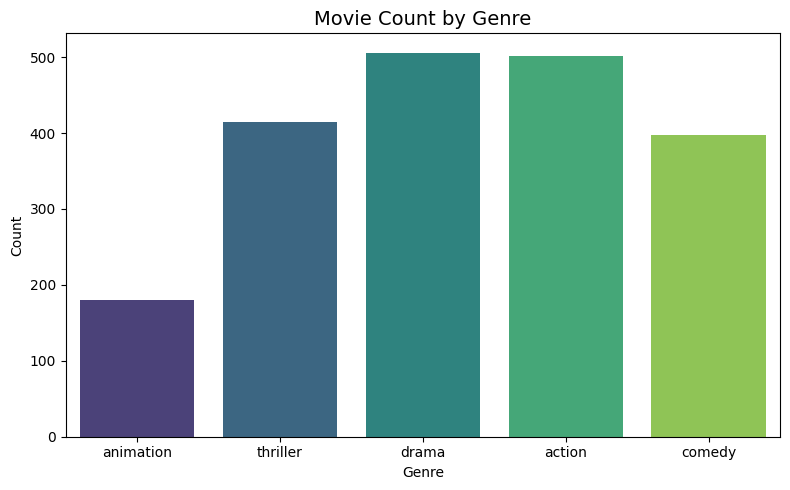

In [7]:
# how many movies per genre
plt.figure(figsize=(8,5))
sns.countplot(x="genre",data=df,palette="viridis")
plt.title("Movie Count by Genre",fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

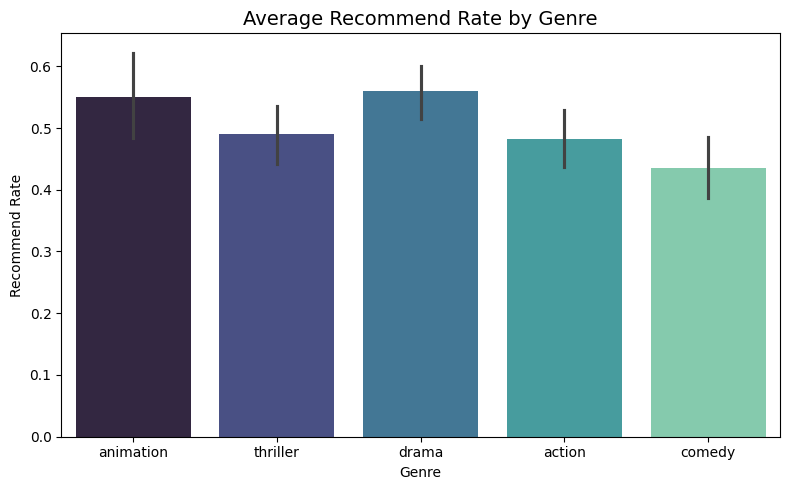

In [8]:
# recommend rate per genre - which genres get recommended more
plt.figure(figsize=(8,5))
sns.barplot(x="genre",y="recommend",data=df,palette="mako")
plt.title("Average Recommend Rate by Genre",fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Recommend Rate")
plt.tight_layout()
plt.show()

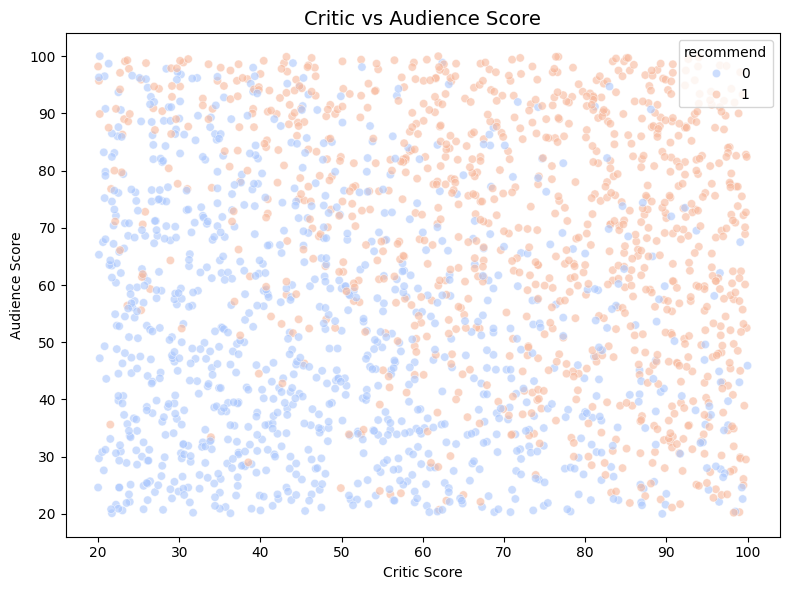

In [9]:
# critic vs audience score, colored by recommend label
plt.figure(figsize=(8,6))
sns.scatterplot(x="critic_score",y="audience_score",hue="recommend",data=df,palette="coolwarm",alpha=0.6)
plt.title("Critic vs Audience Score",fontsize=14)
plt.xlabel("Critic Score")
plt.ylabel("Audience Score")
plt.tight_layout()
plt.show()

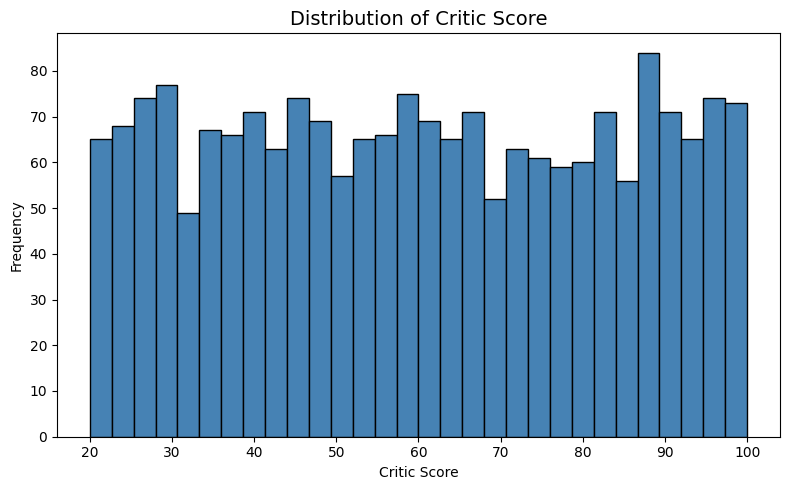

In [10]:
# spread of critic score
plt.figure(figsize=(8,5))
plt.hist(df["critic_score"],bins=30,color="steelblue",edgecolor="black")
plt.title("Distribution of Critic Score",fontsize=14)
plt.xlabel("Critic Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
## FEATURE ENGINEERING
# average of critic and audience score - single quality signal
df["avg_score"]=(df["critic_score"]+df["audience_score"])/2
# bucket release year into decade
df["decade"]=(df["release_year"]//10)*10
# flag for movies that have won at least one award
df["is_award_winner"]=(df["num_awards"]>0).astype(int)
# how far the critic and audience disagree
df["score_gap"]=(df["critic_score"]-df["audience_score"]).abs()
df.head()

,movie_id,genre,language,runtime_min,critic_score,audience_score,release_year,num_awards,recommend,avg_score,decade,is_award_winner,score_gap
0,1,animation,hindi,128,26.8,90.9,2010,5,1,58.85,2010,1,64.1
1,2,animation,english,105,63.5,95.6,2018,6,1,79.55,2010,1,32.1
2,3,thriller,english,168,92.7,68.6,2013,2,1,80.65,2010,1,24.1
3,4,animation,english,165,33.5,42.3,2012,11,0,37.90,2010,1,8.8
4,5,animation,english,177,83.1,81.7,2015,4,1,82.40,2010,1,1.4


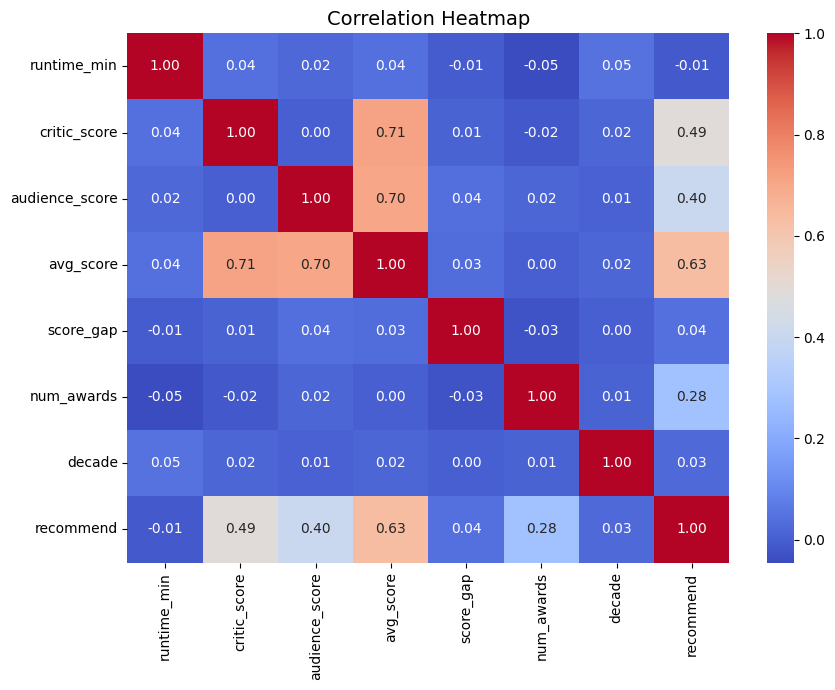

In [12]:
# correlation heatmap of numeric features including the new ones
plt.figure(figsize=(9,7))
num_cols=["runtime_min","critic_score","audience_score","avg_score","score_gap","num_awards","decade","recommend"]
sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap",fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['genre']=le.fit_transform(df['genre'])
df['language']=le.fit_transform(df['language'])

In [14]:
## RECOMMENDATION TARGET - is this movie worth recommending?
df['recommend'].value_counts()

recommend
1    1000
0    1000
Name: count, dtype: int64

In [15]:
X=df.drop(['recommend'],axis=1)
y=df['recommend']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
##SVM CLASSIFIER (SVC)
from sklearn.svm import SVC
classifier=SVC(kernel="rbf",C=1.0,gamma="scale",random_state=42)
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.815


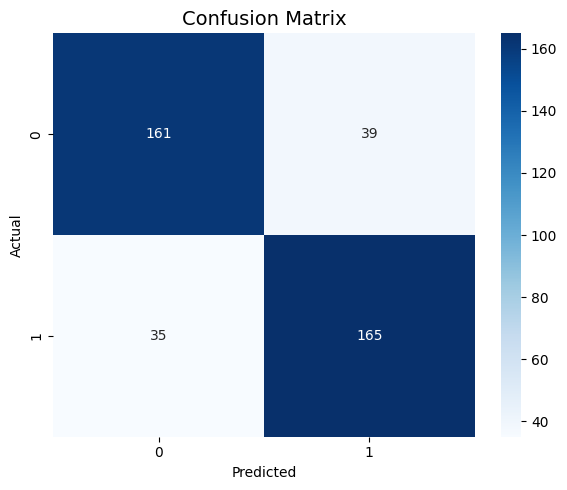

In [19]:
# confusion matrix - simple view of where the model gets it right/wrong
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix",fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()